# Estrategias de trading con opciones

Como ya sabemos 

# Greek Black-Scholes

In [1]:
import pandas as pd
import numpy as np

from pathlib import Path

from scipy.interpolate import LinearNDInterpolator, NearestNDInterpolator, interp1d
from scipy.optimize import brentq

from scipy.stats import norm

import matplotlib.pyplot as plt
import plotly.graph_objects as go
import seaborn as sns

In [2]:
df_bs = pd.DataFrame({
    "fecha_obs": ["22-ene", "29-ene", "05-feb", "10-feb", "17-feb", "19-feb", "24-feb", "26-feb", "05-mar", "17-mar", "19-mar", "25-mar", "26-mar"],
    "fecha_venc": ["09-abr"] * 13,
    "dias_restantes": [77, 70, 63, 58, 51, 49, 44, 42, 35, 23, 21, 15, 14],
    "mes_idx": [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
    "S": [234.34, 241.73, 222.69, 206.96, 201.15, 204.44, 208.56, 207.92, 218.94, 213.50, 209.18, 211.71, 207.54],
    "T": [0.211, 0.192, 0.173, 0.159, 0.140, 0.134, 0.121, 0.115, 0.096, 0.063, 0.058, 0.041, 0.038],
    "sigma": [0.3046, 0.2990, 0.2748, 0.3022, 0.2893, 0.2857, 0.2902, 0.2871, 0.2929, 0.2886, 0.2884, 0.2940, 0.2945],
    "r_cont": [0.0417] * 13,
})

meses_es = {
    "ene": 1,
    "feb": 2,
    "mar": 3,
    "abr": 4,
    "may": 5,
    "jun": 6,
    "jul": 7,
    "ago": 8,
    "sep": 9,
    "oct": 10,
    "nov": 11,
    "dic": 12,
}

def parse_fecha_es(fecha_str, year=2026):
    dia, mes = fecha_str.strip().lower().split("-")
    return pd.Timestamp(year=year, month=meses_es[mes], day=int(dia))

df_bs["fecha_obs"] = df_bs["fecha_obs"].apply(parse_fecha_es)
df_bs["fecha_venc"] = df_bs["fecha_venc"].apply(parse_fecha_es)

df_bs.set_index("fecha_obs")

,fecha_venc,dias_restantes,mes_idx,S,T,sigma,r_cont
fecha_obs,,,,,,,
2026-01-22,2026-04-09,77,0,234.34,0.211,0.3046,0.0417
2026-01-29,2026-04-09,70,1,241.73,0.192,0.2990,0.0417
2026-02-05,2026-04-09,63,2,222.69,0.173,0.2748,0.0417
2026-02-10,2026-04-09,58,3,206.96,0.159,0.3022,0.0417
2026-02-17,2026-04-09,51,4,201.15,0.140,0.2893,0.0417
2026-02-19,2026-04-09,49,5,204.44,0.134,0.2857,0.0417
2026-02-24,2026-04-09,44,6,208.56,0.121,0.2902,0.0417
2026-02-26,2026-04-09,42,7,207.92,0.115,0.2871,0.0417
2026-03-05,2026-04-09,35,8,218.94,0.096,0.2929,0.0417


In [3]:
df_K = pd.DataFrame({
    "K": [140.00, 170.00, 195.00, 212.50, 227.50, 234.34, 252.50, 270.00, 280.00, 290.00, 300.00]
})

In [4]:
def bs_d1(S, K, r, sigma, T, q=0.0):
    S, K, r, sigma, T, q = map(np.asarray, (S, K, r, sigma, T, q))
    return (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))

def bs_d2(S, K, r, sigma, T, q=0.0):
    return bs_d1(S, K, r, sigma, T, q) - sigma * np.sqrt(T)

def bs_call_price(S, K, r, sigma, T, q=0.0):
    d1 = bs_d1(S, K, r, sigma, T, q)
    d2 = bs_d2(S, K, r, sigma, T, q)
    return S * np.exp(-q * T) * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

def calc_count_int(M : float, r: float, T : float) -> float:
    return M * np.exp(r * T)


In [5]:
def call_premium_table(df_bs, df_K, q=0.0, time_col="fecha_obs"):
    base = (
        df_bs.assign(
            fecha_label=lambda x: pd.to_datetime(x[time_col]).map(
                lambda d: f"{d.year}-{d.month}-{d.day}"
            )
        )[["fecha_label", "S", "T", "sigma", "r_cont"]]
        .rename(columns={"fecha_label": "fecha"})
    )

    return (
        base.merge(df_K[["K"]], how="cross")
        .assign(
            call_price=lambda x: bs_call_price(
                S=x["S"],
                K=x["K"],
                r=x["r_cont"],
                sigma=x["sigma"],
                T=x["T"],
                q=q,
            )
        )
        .pivot(index="K", columns="fecha", values="call_price")
        .sort_index()
        .round(2)
    )


In [6]:
tabla_primas = call_premium_table(df_bs, df_K)
tabla_primas.iloc[:, 0] = [123.80, 90.87, 66.60, 42.45, 22.05, 14.50, 4.85, 1.63, 0.76, 0.70 ,0.33]
tabla_primas

fecha,2026-1-22,2026-1-29,2026-2-10,2026-2-17,2026-2-19,2026-2-24,2026-2-26,2026-2-5,2026-3-17,2026-3-19,2026-3-25,2026-3-26,2026-3-5
K,,,,,,,,,,,,,
140.00,123.80,102.85,67.89,61.97,65.22,69.26,68.59,83.70,73.87,69.52,71.95,67.76,79.50
170.00,90.87,73.11,38.51,32.59,35.65,39.55,38.85,53.97,43.95,39.60,42.00,37.81,49.63
195.00,66.60,48.80,17.66,12.66,14.61,17.36,16.61,30.36,19.70,15.72,17.48,13.62,25.53
212.50,42.45,33.18,8.11,4.74,5.66,7.10,6.48,16.82,6.96,4.54,4.82,2.84,11.97
227.50,22.05,21.87,3.53,1.64,1.99,2.58,2.22,8.71,1.78,0.90,0.76,0.31,4.81
234.34,14.50,17.56,2.30,0.94,1.15,1.51,1.25,6.14,0.82,0.36,0.26,0.08,2.91
252.50,4.85,8.95,0.64,0.18,0.22,0.29,0.22,2.10,0.07,0.02,0.01,0.00,0.59
270.00,1.63,4.12,0.16,0.03,0.04,0.05,0.03,0.61,0.00,0.00,0.00,0.00,0.09
280.00,0.76,2.51,0.07,0.01,0.01,0.01,0.01,0.28,0.00,0.00,0.00,0.00,0.03


In [7]:
tabla_primas.sum(axis = 0)

fecha
2026-1-22    368.54
2026-1-29    315.27
2026-2-10    138.91
2026-2-17    114.76
2026-2-19    124.55
2026-2-24    137.71
2026-2-26    134.26
2026-2-5     202.86
2026-3-17    147.15
2026-3-19    130.66
2026-3-25    137.28
2026-3-26    122.42
2026-3-5     175.07
dtype: float64

## With out strategies

En este ejercicio consideraremos una estretegia donde no consideran estrategias de convertura para cubrir los movimientos de la cartarea.

Por tanto considerando que tomamos una posición short sobre financial options call tenemos que a nosotro nos pagan una cantidad de

In [8]:
total_primes = tabla_primas.iloc[:, 0].sum()
total_primes

np.float64(368.53999999999996)

En primas por la venta de las opciones

Considerando lo anterior, si evaluamos cuales de las opciones terminaron in the mony al final del tiempo $T$ tenemos que

In [9]:
df_bs.iloc[-1]["S"] > df_K

,K
0,True
1,True
2,True
3,False
4,False
5,False
6,False
7,False
8,False
9,False


3 de las 10 opciones se habrian ejersido y por tanto tendriamos que comprar el activo al precio spot y venderlo al precio strike, en ste sentido

In [10]:
stock_sell = df_K[df_bs.iloc[-1]["S"] > df_K]
stock_sell = stock_sell.fillna(0)
stock_sell

,K
0,140.0
1,170.0
2,195.0
3,0.0
4,0.0
5,0.0
6,0.0
7,0.0
8,0.0
9,0.0


In [11]:
# Resultado neto
total_primes_invest = calc_count_int(M = total_primes, r = df_bs.loc[0, "r_cont"], T=df_bs.loc[0, "T"])

result_tradeoff = total_primes_invest + (stock_sell.sum() - df_bs.iloc[-1]["S"] * 3)

Por tanto nuestra ganancia perdida por esta estrategia se encuentra en

In [12]:
result_tradeoff

K    254.17698
dtype: float64

# Delta Hedging

## Theory

Como ya sabemo la dinamica de un portafolio $\Pi$ esta dado por su diferencial $d\Pi$ por tanto si consideramos el modelo

$$
d\Pi = Q_1dS_t + Q_2dc(S_t, t)
$$

tenemos que con una simple apliación el lema de Itô para $c(S_t,t)$:

$$
dc(S_t,t) =
\frac{\partial c}{\partial t}dt +
\frac{\partial c}{\partial S_t}dS_t +
\frac{1}{2}\sigma^2 S_t^2 \frac{\partial^2 c}{\partial S_t^2}dt
$$

Sustituyendo en $d\Pi_t$:

$$
d\Pi_t =
Q_1\, dS_t +
Q_2\left(
\frac{\partial c}{\partial t},dt +
\frac{\partial c}{\partial S_t}\,dS_t +
\frac{1}{2}\sigma^2 S_t^2 \frac{\partial^2 c}{\partial S_t^2}\,dt
\right)
$$

Obtenemos la forma factorizada por diferenciales:

$$
d\Pi_t =
\left(
Q_1 + Q_2 \frac{\partial c}{\partial S_t}
\right)dS_t
+
Q_2\left(
\frac{\partial c}{\partial t}
+
\frac{1}{2}\sigma^2 S_t^2 \frac{\partial^2 c}{\partial S_t^2}
\right)dt
$$

La cual en este punto deja bastante claro cuales son los terminos que determinan el grado de incertidumbre incorporado en el modelo. Por tanto si $dS_t$ es la parte del modelo que incorpora el riesgo o la incetidumbre en el mismo por ser proceso estocastico deberiamos de tratar de definir cantidades de $Q_1$ y $Q_2$ de tal manera que podamos eliminar este termino estocastico.

Aquí es donde justamente se incorpora la idea del **delta hedging** la cual es tomar $Q_1$ y $Q_2$ de tal manera que el factor de incertidumbre $dS_t$ pueda ser eliminado.

El término estocástico está dado por

$$
\left(
Q_1 + Q_2 \frac{\partial c}{\partial S_t}
\right)dS_t
$$

Por lo tanto, para eliminar la incertidumbre se impone la condición de **neutralidad delta**:

$$
Q_1 + Q_2 \frac{\partial c}{\partial S_t} = 0
$$

de donde

$$
Q_1 = - Q_2 \frac{\partial c}{\partial S_t}
$$

Sustituyendo esta elección en $d\Pi_t$, el término en $dS_t$ se neutraliza (elimina) y se obtiene un portafolio delta-neutral:

$$
d\Pi_t^{(\Delta)} =
Q_2\left(
\frac{\partial c}{\partial t}
+
\frac{1}{2}\sigma^2 S_t^2 \frac{\partial^2 c}{\partial S_t^2}
\right)dt
$$

Es decir, el diferencial del portafolio ya no depende de $dS_t$, sino únicamente de $dt$, por lo que queda localmente libre de riesgo.


Por tanto nuestra estrategía donde si $Q_2 = -1$ consisten en determinar la cantidad

$$
Q_1 = \frac{\partial c}{\partial S_t}
$$

De esta forma ahora nuestro segundo problema se encuentra en determinar como podemos calcular el $\Delta$ de un portafolio de opciones

Para ello, si consideramos que el valor de un call $C(S_t, t)$ está dado por

$$
C(S_t, t) = N(d_1)S_t - Ke^{-r(T-t)}N(d_2)
$$

donde

$$
d_1 = \frac{\ln\left(\frac{S_t}{K}\right) + \left(r+\frac{1}{2}\sigma^2\right)(T-t)}{\sigma\sqrt{T-t}}
\qquad \text{y} \qquad
d_2 = d_1 - \sigma\sqrt{T-t},
$$

el cálculo de la parcial de $C(S_t, t)$ respecto de $S_t$ se obtiene aplicando la regla del producto y la regla de la cadena:

$$
\Delta_{call} = \frac{\partial C}{\partial S_t} =
\frac{\partial}{\partial S_t}\left(S_tN(d_1)\right) -
\frac{\partial}{\partial S_t}\left(Ke^{-r(T-t)}N(d_2)\right)
$$

Como $Ke^{-r(T-t)}$ es constante respecto de $S_t$, entonces

$$
\frac{\partial C}{\partial S_t} =
N(d_1) + S_t N'(d_1)\frac{\partial d_1}{\partial S_t} -
Ke^{-r(T-t)}N'(d_2)\frac{\partial d_2}{\partial S_t}
$$

donde $N'(x)=\phi(x)$, con $\phi(x)$ la densidad de la normal estándar.

Ahora, como

$$
\frac{\partial d_1}{\partial S_t} =
\frac{1}{S_t\sigma\sqrt{T-t}}
\qquad \text{y} \qquad
\frac{\partial d_2}{\partial S_t} =
\frac{1}{S_t\sigma\sqrt{T-t}},
$$

se tiene

$$
\frac{\partial C}{\partial S_t} =
N(d_1) +
S_t\phi(d_1)\frac{1}{S_t\sigma\sqrt{T-t}} -
Ke^{-r(T-t)}\phi(d_2)\frac{1}{S_t\sigma\sqrt{T-t}}
$$

es decir,

$$
\frac{\partial C}{\partial S_t} =
N(d_1) +
\frac{\phi(d_1)}{\sigma\sqrt{T-t}} -
\frac{Ke^{-r(T-t)}\phi(d_2)}{S_t\sigma\sqrt{T-t}}
$$

Utilizando la identidad

$$
S_t\phi(d_1)=Ke^{-r(T-t)}\phi(d_2),
$$

los dos últimos términos se cancelan, por lo que finalmente se obtiene

$$
\frac{\partial C}{\partial S_t}=N(d_1)
$$

Por lo tanto, la delta de un call europeo en el modelo de Black-Scholes es

$$
\Delta_{call} = \frac{\partial C}{\partial S_t}=N(d_1)
$$


## Code

In [13]:
# Calculo de la delta de un call para cada combinacion fecha-strike
def bs_call_delta(S, K, r, sigma, T, q=0.0):
    d1 = bs_d1(S, K, r, sigma, T, q)
    return np.exp(-q * T) * norm.cdf(d1)

def call_delta_table(df_bs, df_K, q=0.0, time_col="fecha_obs", include_details=False):
    # 1. Variables de entrada del modelo en cada fecha.
    base = df_bs[[time_col, "S", "T", "sigma", "r_cont"]].copy()
    base["fecha"] = pd.to_datetime(base[time_col])

    # 2. Una fila por cada combinacion de fecha y strike.
    delta_long = base.merge(df_K[["K"]], how="cross")

    # 3. Calculo explicito de d1 y de la delta del call.
    delta_long["d1"] = bs_d1(
        S=delta_long["S"],
        K=delta_long["K"],
        r=delta_long["r_cont"],
        sigma=delta_long["sigma"],
        T=delta_long["T"],
        q=q,
    )
    
    delta_long["delta_call"] = np.exp(-q * delta_long["T"]) * norm.cdf(delta_long["d1"])

    # 4. Tabla final: strikes en filas y fechas en columnas, en orden cronologico real.
    tabla_delta = (
        delta_long
        .pivot(index="K", columns="fecha", values="delta_call")
        .sort_index()
        .sort_index(axis=1)
        .round(4)
    )
    tabla_delta.columns = tabla_delta.columns.strftime("%Y-%m-%d")
    tabla_delta = tabla_delta.reset_index()

    if include_details:
        return tabla_delta, delta_long

    return tabla_delta


In [14]:
tabla_deltas = call_delta_table(df_bs, df_K)
tabla_deltas

fecha,K,2026-01-22,2026-01-29,2026-02-05,2026-02-10,2026-02-17,2026-02-19,2026-02-24,2026-02-26,2026-03-05,2026-03-17,2026-03-19,2026-03-25,2026-03-26
0,140.00,0.9999,1.0000,1.0000,0.9996,0.9997,0.9999,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
1,170.00,0.9924,0.9975,0.9935,0.9598,0.9518,0.9692,0.9832,0.9848,0.9980,0.9994,0.9989,0.9999,0.9998
2,195.00,0.9260,0.9613,0.9001,0.7288,0.6535,0.7115,0.7783,0.7754,0.9139,0.9072,0.8600,0.9250,0.8733
3,212.50,0.7973,0.8666,0.7020,0.4586,0.3449,0.3959,0.4662,0.4499,0.6622,0.5546,0.4376,0.4984,0.3613
4,227.50,0.6348,0.7223,0.4734,0.2514,0.1517,0.1798,0.2234,0.2043,0.3695,0.2106,0.1273,0.1251,0.0614
5,234.34,0.5528,0.6419,0.3723,0.1799,0.0963,0.1152,0.1459,0.1291,0.2548,0.1125,0.0587,0.0497,0.0197
6,252.50,0.3444,0.4184,0.1638,0.0624,0.0232,0.0279,0.0364,0.0289,0.0692,0.0124,0.0041,0.0019,0.0004
7,270.00,0.1896,0.2365,0.0588,0.0183,0.0045,0.0053,0.0070,0.0049,0.0132,0.0008,0.0002,0.0000,0.0000
8,280.00,0.1273,0.1598,0.0298,0.0084,0.0016,0.0019,0.0024,0.0015,0.0044,0.0001,0.0000,0.0000,0.0000
9,290.00,0.0822,0.1033,0.0142,0.0036,0.0005,0.0006,0.0008,0.0005,0.0013,0.0000,0.0000,0.0000,0.0000


La suma total de las deltas para cada periodo corresponde al total de la exposición en el activo necesaria para convertir al portafolios en $\Delta$-neutral localmente

In [15]:
deltas = tabla_deltas.drop(columns="K").sum(axis=0)
deltas

fecha
2026-01-22    5.6980
2026-01-29    6.1716
2026-02-05    4.7143
2026-02-10    3.6723
2026-02-17    3.2279
2026-02-19    3.4074
2026-02-24    3.6438
2026-02-26    3.5794
2026-03-05    4.2869
2026-03-17    3.7976
2026-03-19    3.4868
2026-03-25    3.6000
2026-03-26    3.3159
dtype: float64

In [16]:
df_delta_strategy = pd.DataFrame(deltas).reset_index().T

df_delta_strategy.columns = df_delta_strategy.loc["fecha"]
df_delta_strategy = df_delta_strategy.drop("fecha")

df_delta_strategy.index = ["Delta"]

delta = pd.to_numeric(df_delta_strategy.loc["Delta"], errors="coerce")

df_delta_strategy.loc["Delta diff"] = delta.diff()
df_delta_strategy.loc["Delta diff", df_delta_strategy.columns[0]] = delta.iloc[0]

df_delta_strategy.loc["Delta * St"] = (
    pd.to_numeric(df_delta_strategy.loc["Delta diff"], errors="coerce").values
    * df_bs.loc[:, "S"].to_numpy()
)

df_delta_strategy.loc["Total gains loss"] = pd.to_numeric(
    df_delta_strategy.loc["Delta * St"], errors="coerce"
).cumsum()

df_delta_strategy


fecha,2026-01-22,2026-01-29,2026-02-05,2026-02-10,2026-02-17,2026-02-19,2026-02-24,2026-02-26,2026-03-05,2026-03-17,2026-03-19,2026-03-25,2026-03-26
Delta,5.698,6.1716,4.7143,3.6723,3.2279,3.4074,3.6438,3.5794,4.2869,3.7976,3.4868,3.6,3.3159
Delta diff,5.698,0.4736,-1.4573,-1.042,-0.4444,0.1795,0.2364,-0.0644,0.7075,-0.4893,-0.3108,0.1132,-0.2841
Delta * St,1335.26932,114.483328,-324.526137,-215.65232,-89.39106,36.69698,49.303584,-13.390048,154.90005,-104.46555,-65.013144,23.965572,-58.962114
Total gains loss,1335.26932,1449.752648,1125.226511,909.574191,820.183131,856.880111,906.183695,892.793647,1047.693697,943.228147,878.215003,902.180575,843.218461


In [17]:
total_primes_invest = calc_count_int(M = total_primes, r = df_bs.loc[0, "r_cont"], T=df_bs.loc[0, "T"])

buy_stocks = df_delta_strategy.iloc[-1,-1]

sell_stocks = stock_sell.sum()

scenario2 = total_primes  + sell_stocks - buy_stocks 
scenario2

K    30.321539
dtype: float64

In [18]:
scenario2 / total_primes

K    0.082275
dtype: float64

# Delta-Gamma Hedging

## Theory

## Code

In [19]:
def bs_call_gamma(S, K, r, sigma, T, q=0.0):
    d1 = bs_d1(S, K, r, sigma, T, q)
    return np.exp(-q * T) * norm.pdf(d1) / (S * sigma * np.sqrt(T))


def lambda_delta_adjustment(S, sigma, T):
    return np.sqrt(0.5 * T) * S * sigma**2


def _pivot_metric_table(df, value_col):
    table = (
        df.pivot(index="K", columns="fecha", values=value_col)
        .sort_index()
        .sort_index(axis=1)
        .round(4)
    )
    table.columns = table.columns.strftime("%Y-%m-%d")
    return table.reset_index()


def build_adjusted_delta_tables(df_bs, df_K, q=0.0, time_col="fecha_obs", include_details=False):
    base = df_bs[[time_col, "S", "T", "sigma", "r_cont"]].copy()
    base["fecha"] = pd.to_datetime(base[time_col])

    greeks = base.merge(df_K[["K"]], how="cross")
    greeks["d1"] = bs_d1(
        S=greeks["S"],
        K=greeks["K"],
        r=greeks["r_cont"],
        sigma=greeks["sigma"],
        T=greeks["T"],
        q=q,
    )

    greeks["delta_call"] = bs_call_delta(
        S=greeks["S"],
        K=greeks["K"],
        r=greeks["r_cont"],
        sigma=greeks["sigma"],
        T=greeks["T"],
        q=q,
    )
    greeks["gamma_call"] = bs_call_gamma(
        S=greeks["S"],
        K=greeks["K"],
        r=greeks["r_cont"],
        sigma=greeks["sigma"],
        T=greeks["T"],
        q=q,
    )
    greeks["lambda_ajuste"] = lambda_delta_adjustment(
        S=greeks["S"],
        sigma=greeks["sigma"],
        T=greeks["T"],
    )
    greeks["delta_ajustada"] = greeks["delta_call"] - greeks["lambda_ajuste"] * greeks["gamma_call"]

    tables = {
        "delta": _pivot_metric_table(greeks, "delta_call"),
        "gamma": _pivot_metric_table(greeks, "gamma_call"),
        "lambda": _pivot_metric_table(greeks, "lambda_ajuste"),
        "delta_ajustada": _pivot_metric_table(greeks, "delta_ajustada"),
    }

    if include_details:
        return tables, greeks

    return tables


def build_hedging_strategy(exposure_by_date, spot_series, exposure_label):
    strategy = pd.DataFrame(exposure_by_date).reset_index().T
    strategy.columns = strategy.loc["fecha"]
    strategy = strategy.drop("fecha")
    strategy.index = [exposure_label]

    exposure = pd.to_numeric(strategy.loc[exposure_label], errors="coerce")
    diff_label = f"{exposure_label} diff"

    strategy.loc[diff_label] = exposure.diff()
    strategy.loc[diff_label, strategy.columns[0]] = exposure.iloc[0]
    strategy.loc["Rebalanceo * St"] = pd.to_numeric(
        strategy.loc[diff_label], errors="coerce"
    ).to_numpy() * np.asarray(spot_series)
    strategy.loc["Total gains loss"] = pd.to_numeric(
        strategy.loc["Rebalanceo * St"], errors="coerce"
    ).cumsum()

    return strategy


tablas_ajuste, detalle_ajuste = build_adjusted_delta_tables(
    df_bs,
    df_K,
    include_details=True,
)

tabla_delta_ajustada = tablas_ajuste["delta_ajustada"]
delta_ajustada_total = tabla_delta_ajustada.drop(columns="K").sum(axis=0)

df_delta_gamma_strategy = build_hedging_strategy(
    exposure_by_date=delta_ajustada_total,
    spot_series=df_bs["S"],
    exposure_label="Delta ajustada",
)

tabla_delta_ajustada

fecha,K,2026-01-22,2026-01-29,2026-02-05,2026-02-10,2026-02-17,2026-02-19,2026-02-24,2026-02-26,2026-03-05,2026-03-17,2026-03-19,2026-03-25,2026-03-26
0,140.00,0.9999,1.0000,1.0000,0.9993,0.9995,0.9998,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
1,170.00,0.9879,0.9959,0.9899,0.9412,0.9313,0.9552,0.9747,0.9771,0.9967,0.9989,0.9981,0.9998,0.9996
2,195.00,0.8958,0.9436,0.8660,0.6580,0.5781,0.6425,0.7173,0.7146,0.8814,0.8733,0.8146,0.8956,0.8300
3,212.50,0.7365,0.8210,0.6346,0.3738,0.2696,0.3181,0.3846,0.3696,0.5865,0.4740,0.3572,0.4154,0.2833
4,227.50,0.5538,0.6514,0.3961,0.1833,0.1036,0.1268,0.1621,0.1467,0.2914,0.1517,0.0848,0.0823,0.0361
5,234.34,0.4677,0.5630,0.2988,0.1238,0.0614,0.0759,0.0990,0.0864,0.1883,0.0735,0.0348,0.0284,0.0098
6,252.50,0.2651,0.3358,0.1158,0.0361,0.0120,0.0149,0.0201,0.0155,0.0416,0.0059,0.0016,0.0006,0.0001
7,270.00,0.1312,0.1713,0.0360,0.0087,0.0018,0.0022,0.0030,0.0020,0.0062,0.0002,0.0000,0.0000,0.0000
8,280.00,0.0824,0.1084,0.0167,0.0035,0.0005,0.0007,0.0009,0.0005,0.0017,0.0000,0.0000,-0.0000,-0.0000
9,290.00,0.0495,0.0653,0.0072,0.0013,0.0001,0.0002,0.0002,0.0001,0.0004,0.0000,0.0000,-0.0000,-0.0000


In [20]:
df_delta_gamma_strategy

fecha,2026-01-22,2026-01-29,2026-02-05,2026-02-10,2026-02-17,2026-02-19,2026-02-24,2026-02-26,2026-03-05,2026-03-17,2026-03-19,2026-03-25,2026-03-26
Delta ajustada,5.1984,5.6932,4.364,3.3295,2.9579,3.1363,3.362,3.3125,3.9943,3.5775,3.2911,3.4221,3.1589
Delta ajustada diff,5.1984,0.4948,-1.3292,-1.0345,-0.3716,0.1784,0.2257,-0.0495,0.6818,-0.4168,-0.2864,0.131,-0.2632
Rebalanceo * St,1218.193056,119.608004,-295.999548,-214.10012,-74.74734,36.472096,47.071992,-10.29204,149.273292,-88.9868,-59.909152,27.73401,-54.624528
Total gains loss,1218.193056,1337.80106,1041.801512,827.701392,752.954052,789.426148,836.49814,826.2061,975.479392,886.492592,826.58344,854.31745,799.692922


In [21]:
total_primes_invest

buy_stocks = df_delta_gamma_strategy.iloc[-1,-1]

sell_stocks = stock_sell.sum()

scenario3 = total_primes  + sell_stocks - buy_stocks 
scenario3

K    73.847078
dtype: float64

# Greek Black-Scholes with implied volatility

## Theory

## Code

In [47]:
def normalize_option_type(option_type):
    option_type = str(option_type).strip().lower()
    if option_type in {"c", "call"}:
        return "call"
    if option_type in {"p", "put"}:
        return "put"
    raise ValueError("option_type debe ser 'call' o 'put'.")


def bs_option_price(S, K, r, sigma, T, option_type="call", q=0.0):
    option_type = normalize_option_type(option_type)
    S, K, r, sigma, T, q = map(np.asarray, (S, K, r, sigma, T, q))

    intrinsic = np.where(
        option_type == "call",
        np.maximum(S - K, 0.0),
        np.maximum(K - S, 0.0),
    )

    valid_time = T > 0
    price = intrinsic.astype(float) if isinstance(intrinsic, np.ndarray) else float(intrinsic)

    if np.any(valid_time):
        d1 = bs_d1(S, K, r, sigma, T, q)
        d2 = bs_d2(S, K, r, sigma, T, q)
        call_price = S * np.exp(-q * T) * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
        put_price = K * np.exp(-r * T) * norm.cdf(-d2) - S * np.exp(-q * T) * norm.cdf(-d1)
        full_price = np.where(option_type == "call", call_price, put_price)
        price = np.where(valid_time, full_price, intrinsic)

    return price


def option_price_bounds(S, K, r, T, option_type="call", q=0.0):
    option_type = normalize_option_type(option_type)
    discounted_spot = S * np.exp(-q * T)
    discounted_strike = K * np.exp(-r * T)

    if option_type == "call":
        lower = max(discounted_spot - discounted_strike, 0.0)
        upper = discounted_spot
    else:
        lower = max(discounted_strike - discounted_spot, 0.0)
        upper = discounted_strike

    return lower, upper


def implied_volatility(
    market_price,
    S,
    K,
    r,
    T,
    option_type="call",
    q=0.0,
    sigma_min=1e-6,
    sigma_max=3.0,
    price_tol=1e-8,
    max_sigma_expansions=8,
):
    option_type = normalize_option_type(option_type)

    if pd.isna(market_price) or pd.isna(S) or pd.isna(K) or pd.isna(r) or pd.isna(T):
        return np.nan
    if market_price <= 0 or S <= 0 or K <= 0 or T <= 0:
        return np.nan

    lower_bound, upper_bound = option_price_bounds(S, K, r, T, option_type=option_type, q=q)
    if market_price < lower_bound - price_tol or market_price > upper_bound + price_tol:
        return np.nan
    if np.isclose(market_price, lower_bound, atol=price_tol):
        return sigma_min

    def objective(sigma):
        return bs_option_price(S, K, r, sigma, T, option_type=option_type, q=q) - market_price

    sigma_upper = sigma_max
    f_low = objective(sigma_min)
    f_high = objective(sigma_upper)

    expansions = 0
    while f_high < 0 and expansions < max_sigma_expansions:
        sigma_upper *= 2
        f_high = objective(sigma_upper)
        expansions += 1

    if f_low * f_high > 0:
        return np.nan

    return brentq(objective, sigma_min, sigma_upper)


def add_surface_coordinates(df_quotes, spot_col="S", strike_col="K", maturity_col="T", rate_col="r_cont", dividend_col=None):
    quotes = df_quotes.copy()
    dividend = 0.0 if dividend_col is None else quotes[dividend_col]

    quotes["forward"] = quotes[spot_col] * np.exp((quotes[rate_col] - dividend) * quotes[maturity_col])
    quotes["moneyness"] = quotes[spot_col] / quotes[strike_col]
    quotes["log_moneyness"] = np.log(quotes[spot_col] / quotes[strike_col])
    quotes["forward_moneyness"] = quotes[strike_col] / quotes["forward"]
    quotes["log_forward_moneyness"] = np.log(quotes["forward_moneyness"])

    return quotes


def compute_implied_vols(
    df_quotes,
    price_col="market_price",
    spot_col="S",
    strike_col="K",
    rate_col="r_cont",
    maturity_col="T",
    option_type_col="option_type",
    dividend_col=None,
):
    quotes = add_surface_coordinates(
        df_quotes,
        spot_col=spot_col,
        strike_col=strike_col,
        maturity_col=maturity_col,
        rate_col=rate_col,
        dividend_col=dividend_col,
    )

    quotes["q"] = 0.0 if dividend_col is None else quotes[dividend_col]
    quotes["iv"] = quotes.apply(
        lambda row: implied_volatility(
            market_price=row[price_col],
            S=row[spot_col],
            K=row[strike_col],
            r=row[rate_col],
            T=row[maturity_col],
            option_type=row[option_type_col],
            q=row["q"],
        ),
        axis=1,
    )

    return quotes.drop(columns="q")


def build_vol_surface_table(df_iv, x_col="log_forward_moneyness", y_col="T", iv_col="iv", decimals=4):
    table = (
        df_iv.pivot_table(index=x_col, columns=y_col, values=iv_col, aggfunc="mean")
        .sort_index()
        .sort_index(axis=1)
        .round(decimals)
    )
    return table.reset_index()


def fit_vol_smile_interpolator(df_iv, x_col="log_forward_moneyness", iv_col="iv", maturity_col="T"):
    smile_data = (
        df_iv[[x_col, maturity_col, iv_col]]
        .dropna()
        .groupby([x_col, maturity_col], as_index=False)[iv_col]
        .mean()
        .sort_values(x_col)
    )

    if smile_data[maturity_col].nunique() != 1:
        raise ValueError("El smile requiere un unico vencimiento.")
    if smile_data[x_col].nunique() < 2:
        raise ValueError("Se requieren al menos dos strikes para interpolar un smile.")

    maturity = float(smile_data[maturity_col].iloc[0])
    interpolator = interp1d(
        smile_data[x_col],
        smile_data[iv_col],
        kind="linear",
        bounds_error=False,
        fill_value=(smile_data[iv_col].iloc[0], smile_data[iv_col].iloc[-1]),
    )

    def smile_fn(x, T=None):
        if T is not None and not np.isclose(np.asarray(T, dtype=float), maturity).all():
            raise ValueError("Este interpolador solo es valido para el vencimiento usado al ajustar el smile.")
        return np.asarray(interpolator(x), dtype=float)

    return smile_fn


def fit_vol_surface_interpolator(df_iv, x_col="log_forward_moneyness", y_col="T", iv_col="iv"):
    surface_data = (
        df_iv[[x_col, y_col, iv_col]]
        .dropna()
        .groupby([x_col, y_col], as_index=False)[iv_col]
        .mean()
    )

    if surface_data[x_col].nunique() < 2 or surface_data[y_col].nunique() < 2 or len(surface_data) < 3:
        raise ValueError("La superficie requiere varios strikes y varios vencimientos en la misma fecha.")

    points = surface_data[[x_col, y_col]].to_numpy(dtype=float)
    values = surface_data[iv_col].to_numpy(dtype=float)

    linear = LinearNDInterpolator(points, values, fill_value=np.nan)
    nearest = NearestNDInterpolator(points, values)

    def surface_fn(x, T):
        linear_value = np.asarray(linear(x, T), dtype=float)
        nearest_value = np.asarray(nearest(x, T), dtype=float)
        return np.where(np.isnan(linear_value), nearest_value, linear_value)

    return surface_fn


def prepare_vol_model(
    df_quotes,
    valuation_date=None,
    date_col="fecha_obs",
    x_col="log_forward_moneyness",
    y_col="T",
    iv_col="iv",
):
    quotes = df_quotes.copy()

    if date_col in quotes.columns:
        quotes[date_col] = pd.to_datetime(quotes[date_col])
        if valuation_date is not None:
            valuation_date = pd.to_datetime(valuation_date)
            quotes = quotes.loc[quotes[date_col] == valuation_date].copy()
        elif quotes[date_col].nunique() > 1:
            raise ValueError("Una superficie de volatilidad se construye para una sola fecha de valuacion.")

    quotes_iv = compute_implied_vols(quotes)
    quotes_iv = quotes_iv.dropna(subset=[iv_col, x_col, y_col]).copy()
    vol_table = build_vol_surface_table(quotes_iv, x_col=x_col, y_col=y_col, iv_col=iv_col)

    if quotes_iv[y_col].nunique() == 1:
        model_type = "smile"
        vol_fn = fit_vol_smile_interpolator(quotes_iv, x_col=x_col, iv_col=iv_col, maturity_col=y_col)
    else:
        model_type = "surface"
        vol_fn = fit_vol_surface_interpolator(quotes_iv, x_col=x_col, y_col=y_col, iv_col=iv_col)

    return {
        "model_type": model_type,
        "quotes_iv": quotes_iv,
        "vol_table": vol_table,
        "vol_fn": vol_fn,
        "x_col": x_col,
        "y_col": y_col,
        "iv_col": iv_col,
    }


def evaluate_vol_model(vol_model, S, K, T, r, q=0.0):
    if vol_model["x_col"] == "log_forward_moneyness":
        forward = S * np.exp((r - q) * T)
        x_value = np.log(K / forward)
    elif vol_model["x_col"] == "log_moneyness":
        x_value = np.log(S / K)
    else:
        raise ValueError("El evaluador solo soporta log_forward_moneyness y log_moneyness.")

    vol_value = vol_model["vol_fn"](x_value, T)
    return float(np.asarray(vol_value).reshape(-1)[0])


def build_quotes_from_price_table(price_table, df_bs, option_type="call", price_col="market_price", time_col="fecha_obs"):
    quotes = (
        price_table.reset_index()
        .melt(id_vars="K", var_name=time_col, value_name=price_col)
        .assign(
            option_type=normalize_option_type(option_type),
            fecha_obs=lambda x: pd.to_datetime(x[time_col]),
        )
        .merge(df_bs[[time_col, "S", "T", "r_cont"]], on=time_col, how="left")
    )

    return quotes[[time_col, "option_type", price_col, "S", "K", "T", "r_cont"]]


def load_surface_quotes_csv(
    csv_path,
    valuation_date=None,
    rate=0.0417,
    dividend_yield=0.0,
    use_otm_only=True,
):
    csv_path = Path(csv_path)
    if not csv_path.exists():
        alt_path = Path("src/proyect") / csv_path.name
        if alt_path.exists():
            csv_path = alt_path
        else:
            raise FileNotFoundError(f"No se encontro el archivo: {csv_path}")

    quotes = pd.read_csv(csv_path)
    quotes = quotes.drop(columns=["Unnamed: 0"], errors="ignore")

    if "date" in quotes.columns:
        quotes["date"] = pd.to_datetime(quotes["date"])
    if "expiration_date" in quotes.columns:
        quotes["expiration_date"] = pd.to_datetime(quotes["expiration_date"])
    if "option_type" in quotes.columns:
        quotes["option_type"] = quotes["option_type"].map(normalize_option_type)

    if valuation_date is not None and "date" in quotes.columns:
        valuation_date = pd.to_datetime(valuation_date)
        quotes = quotes.loc[quotes["date"] == valuation_date].copy()

    if "mid" not in quotes.columns and {"bid", "ask"}.issubset(quotes.columns):
        bid = pd.to_numeric(quotes["bid"], errors="coerce")
        ask = pd.to_numeric(quotes["ask"], errors="coerce")
        quotes["mid"] = (bid + ask) / 2

    if "market_price" in quotes.columns:
        quotes["market_price"] = pd.to_numeric(quotes["market_price"], errors="coerce")
    elif "mid" in quotes.columns:
        quotes["market_price"] = pd.to_numeric(quotes["mid"], errors="coerce")
    else:
        raise ValueError("No se encontro una columna de precio de mercado ni una columna 'mid'.")

    spot_source = "S" if "S" in quotes.columns else "underlying_price"
    strike_source = "K" if "K" in quotes.columns else "strike"
    quotes["S"] = pd.to_numeric(quotes[spot_source], errors="coerce")
    quotes["K"] = pd.to_numeric(quotes[strike_source], errors="coerce")

    if "T" in quotes.columns:
        quotes["T"] = pd.to_numeric(quotes["T"], errors="coerce")
    elif {"date", "expiration_date"}.issubset(quotes.columns):
        quotes["T"] = (quotes["expiration_date"] - quotes["date"]).dt.days / 365.0
    else:
        raise ValueError("No fue posible construir T. Se requiere 'T' o las columnas 'date' y 'expiration_date'.")

    if "r_cont" in quotes.columns:
        quotes["r_cont"] = pd.to_numeric(quotes["r_cont"], errors="coerce").fillna(float(rate))
    else:
        quotes["r_cont"] = float(rate)

    if "q" in quotes.columns:
        quotes["q"] = pd.to_numeric(quotes["q"], errors="coerce").fillna(float(dividend_yield))
    else:
        quotes["q"] = float(dividend_yield)

    valid_quotes = (
        (quotes["market_price"] > 0)
        & (quotes["S"] > 0)
        & (quotes["K"] > 0)
        & (quotes["T"] > 0)
    )

    if {"bid", "ask"}.issubset(quotes.columns):
        bid = pd.to_numeric(quotes["bid"], errors="coerce")
        ask = pd.to_numeric(quotes["ask"], errors="coerce")
        valid_quotes &= (bid > 0) & (ask > 0) & (ask >= bid)

    quotes = quotes.loc[valid_quotes].copy()
    quotes["is_otm"] = True

    if use_otm_only and "option_type" in quotes.columns:
        quotes["is_otm"] = (
            ((quotes["option_type"] == "call") & (quotes["K"] >= quotes["S"]))
            | ((quotes["option_type"] == "put") & (quotes["K"] <= quotes["S"]))
        )
        quotes = quotes.loc[quotes["is_otm"]].copy()

    return quotes.reset_index(drop=True)


def summarize_exercise_strikes(df_quotes, exercise_strikes):
    rows = []

    for strike in exercise_strikes:
        strike_quotes = df_quotes.loc[np.isclose(df_quotes["K"], float(strike))].copy()
        min_expiration = pd.NA
        max_expiration = pd.NA

        if not strike_quotes.empty and "expiration_date" in strike_quotes.columns:
            min_expiration = strike_quotes["expiration_date"].min().strftime("%Y-%m-%d")
            max_expiration = strike_quotes["expiration_date"].max().strftime("%Y-%m-%d")

        rows.append(
            {
                "strike": float(strike),
                "observed_in_surface": not strike_quotes.empty,
                "surface_action": "observed" if not strike_quotes.empty else "interpolate",
                "option_types": ", ".join(sorted(strike_quotes["option_type"].unique().tolist())) if not strike_quotes.empty else "",
                "num_quotes": int(len(strike_quotes)),
                "min_expiration": min_expiration,
                "max_expiration": max_expiration,
            }
        )

    return pd.DataFrame(rows)


def format_sigma_row_label(strike):
    strike_label = f"{float(strike):.2f}".rstrip("0").rstrip(".")
    return f"sigma implied {strike_label}"


def classify_surface_evaluation(vol_model, S, K, T, r, q=0.0, maturity_tol_days=1.0):
    quotes_iv = vol_model["quotes_iv"]
    maturity_tol = maturity_tol_days / 365.0

    exact_point = np.isclose(quotes_iv["K"], float(K)) & np.isclose(quotes_iv["T"], float(T), atol=maturity_tol)
    if exact_point.any():
        return "observada"

    same_strike = np.isclose(quotes_iv["K"], float(K))
    if same_strike.any():
        strike_maturities = quotes_iv.loc[same_strike, "T"]
        if strike_maturities.min() - maturity_tol <= float(T) <= strike_maturities.max() + maturity_tol:
            return "interpolada_T"
        return "extrapolada_T"

    target_x = np.log(K / (S * np.exp((r - q) * T)))
    x_min = float(quotes_iv[vol_model["x_col"]].min())
    x_max = float(quotes_iv[vol_model["x_col"]].max())
    t_min = float(quotes_iv["T"].min())
    t_max = float(quotes_iv["T"].max())

    if x_min <= target_x <= x_max and t_min - maturity_tol <= float(T) <= t_max + maturity_tol:
        return "interpolada_superficie"

    return "extrapolada_superficie"


def build_surface_sigma_tables(
    df_bs,
    df_K,
    quotes_csv_path="AMZN_options_base_3m.csv",
    q=0.0,
    rate=0.0417,
    use_otm_only=True,
    time_col="fecha_obs",
):
    market_quotes = load_surface_quotes_csv(
        quotes_csv_path,
        valuation_date=None,
        rate=rate,
        dividend_yield=q,
        use_otm_only=use_otm_only,
    )

    ordered_dates = pd.to_datetime(df_bs[time_col]).tolist()
    records = []
    daily_models = {}

    for _, obs in df_bs[[time_col, "S", "T", "r_cont"]].iterrows():
        valuation_date = pd.to_datetime(obs[time_col])
        daily_quotes = market_quotes.loc[market_quotes["date"] == valuation_date].copy()

        if daily_quotes.empty:
            raise ValueError(f"No hay cotizaciones suficientes para construir la superficie en {valuation_date:%Y-%m-%d}.")

        daily_model = prepare_vol_model(
            daily_quotes,
            valuation_date=valuation_date,
            date_col="date",
        )
        daily_models[valuation_date] = daily_model

        for strike in pd.to_numeric(df_K["K"], errors="coerce"):
            sigma_value = evaluate_vol_model(
                daily_model,
                S=float(obs["S"]),
                K=float(strike),
                T=float(obs["T"]),
                r=float(obs["r_cont"]),
                q=q,
            )
            source_type = classify_surface_evaluation(
                daily_model,
                S=float(obs["S"]),
                K=float(strike),
                T=float(obs["T"]),
                r=float(obs["r_cont"]),
                q=q,
            )

            records.append(
                {
                    "fecha": valuation_date,
                    "K": float(strike),
                    "sigma": float(sigma_value),
                    "fuente_sigma": source_type,
                    "S_objetivo": float(obs["S"]),
                    "T_objetivo": float(obs["T"]),
                    "r_objetivo": float(obs["r_cont"]),
                }
            )

    sigma_long = pd.DataFrame(records)
    strike_order = pd.to_numeric(df_K["K"], errors="coerce").tolist()

    sigma_table = (
        sigma_long.pivot(index="K", columns="fecha", values="sigma")
        .reindex(index=strike_order, columns=ordered_dates)
        .round(4)
    )
    sigma_source_table = (
        sigma_long.pivot(index="K", columns="fecha", values="fuente_sigma")
        .reindex(index=strike_order, columns=ordered_dates)
    )

    sigma_table.index = [format_sigma_row_label(strike) for strike in sigma_table.index]
    sigma_source_table.index = [format_sigma_row_label(strike) for strike in sigma_source_table.index]
    sigma_table.columns = [date.strftime("%Y-%m-%d") for date in ordered_dates]
    sigma_source_table.columns = [date.strftime("%Y-%m-%d") for date in ordered_dates]

    sigma_table_pct = sigma_table.apply(lambda column: column.map(lambda value: f"{value:.2%}" if pd.notna(value) else ""))

    return {
        "sigma_table": sigma_table,
        "sigma_table_pct": sigma_table_pct,
        "sigma_source_table": sigma_source_table,
        "sigma_details": sigma_long,
        "daily_models": daily_models,
    }


amzn_surface_valuation_date = pd.Timestamp("2026-01-22")
exercise_strikes = [140.0, 170.0, 195.0, 212.5, 227.5, 234.34, 252.5, 270.0, 280.0, 290.0, 300.0]

amzn_surface_quotes = load_surface_quotes_csv(
    "AMZN_options_base_3m.csv",
    valuation_date=amzn_surface_valuation_date,
    rate=0.0417,
    dividend_yield=0.0,
    use_otm_only=True,
)

surface_build_summary = pd.DataFrame(
    [
        {
            "valuation_date": amzn_surface_valuation_date.strftime("%Y-%m-%d"),
            "spot": round(float(amzn_surface_quotes["S"].iloc[0]), 2),
            "surface_nodes": int(len(amzn_surface_quotes)),
            "unique_expirations": int(amzn_surface_quotes["expiration_date"].nunique()),
            "unique_strikes": int(amzn_surface_quotes["K"].nunique()),
        }
    ]
)

exercise_strike_summary = summarize_exercise_strikes(amzn_surface_quotes, exercise_strikes)

amzn_surface_model = prepare_vol_model(
    amzn_surface_quotes,
    valuation_date=amzn_surface_valuation_date,
    date_col="date",
)

exercise_strike_summary

,strike,observed_in_surface,surface_action,option_types,num_quotes,min_expiration,max_expiration
0,140.00,False,interpolate,,0,NaN,NaN
1,170.00,False,interpolate,,0,NaN,NaN
2,195.00,True,observed,put,1,2026-05-15,2026-05-15
3,212.50,False,interpolate,,0,NaN,NaN
4,227.50,True,observed,put,4,2026-01-23,2026-02-20
5,234.34,False,interpolate,,0,NaN,NaN
6,252.50,True,observed,call,3,2026-01-30,2026-02-20
7,270.00,True,observed,call,3,2026-02-27,2026-05-15
8,280.00,False,interpolate,,0,NaN,NaN
9,290.00,False,interpolate,,0,NaN,NaN


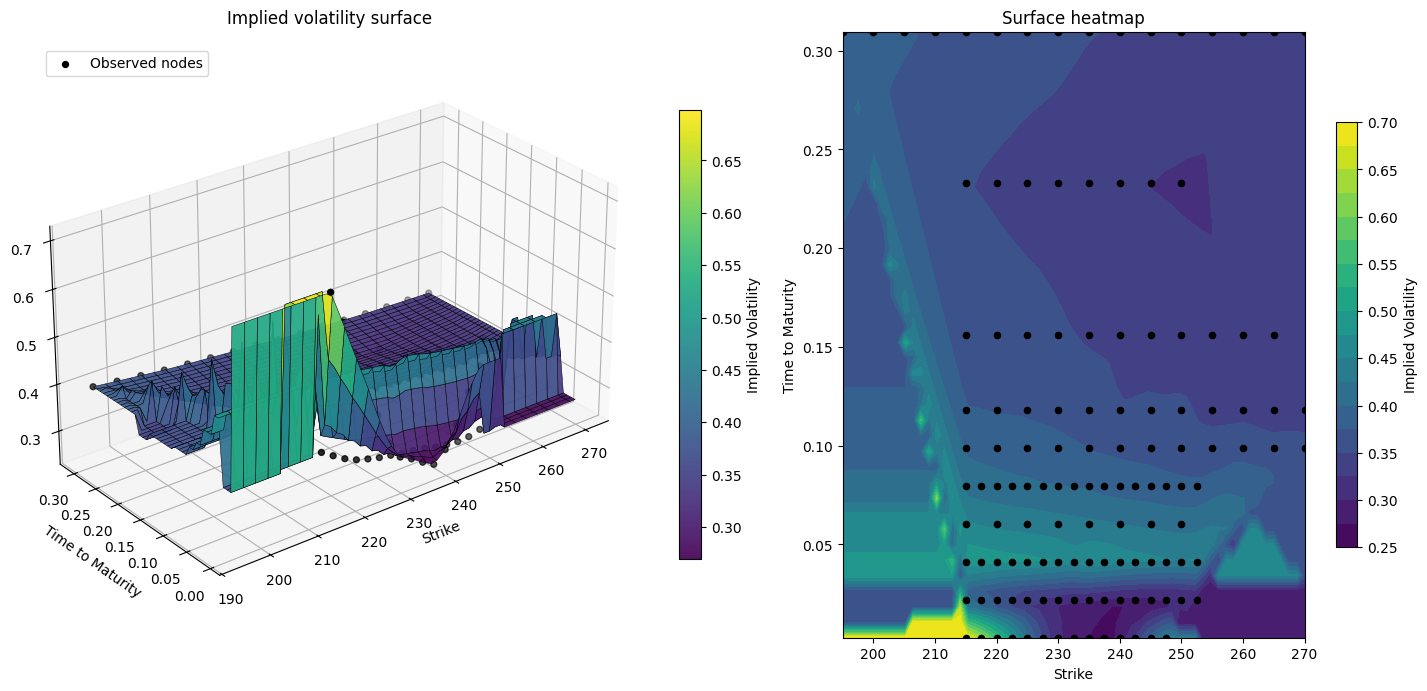

In [48]:
def to_plotly_colorscale(cmap):
    colorscale_map = {
        "viridis": "Viridis",
        "plasma": "Plasma",
        "inferno": "Inferno",
        "magma": "Magma",
        "cividis": "Cividis",
    }
    return colorscale_map.get(str(cmap).lower(), cmap)


def build_strike_surface_plot_grid(
    vol_model,
    strike_min=None,
    strike_max=None,
    maturity_min=None,
    maturity_max=None,
    num_strikes=60,
    num_maturities=40,
    q=0.0,
):
    quotes_iv = vol_model["quotes_iv"].copy()
    S_ref = float(quotes_iv["S"].iloc[0])
    r_ref = float(quotes_iv["r_cont"].iloc[0])
    q_ref = float(quotes_iv["q"].iloc[0]) if "q" in quotes_iv.columns else float(q)

    strike_min = float(quotes_iv["K"].min()) if strike_min is None else float(strike_min)
    strike_max = float(quotes_iv["K"].max()) if strike_max is None else float(strike_max)
    maturity_min = float(quotes_iv["T"].min()) if maturity_min is None else float(maturity_min)
    maturity_max = float(quotes_iv["T"].max()) if maturity_max is None else float(maturity_max)

    strike_grid = np.linspace(strike_min, strike_max, num_strikes)

    if vol_model["model_type"] == "smile":
        maturity = float(quotes_iv["T"].iloc[0])
        iv_curve = np.array([
            evaluate_vol_model(vol_model, S_ref, strike, maturity, r_ref, q=q_ref)
            for strike in strike_grid
        ])
        return {
            "model_type": "smile",
            "strike_grid": strike_grid,
            "maturity": maturity,
            "iv_curve": iv_curve,
            "quotes_iv": quotes_iv,
        }

    maturity_grid = np.linspace(maturity_min, maturity_max, num_maturities)
    strike_mesh, maturity_mesh = np.meshgrid(strike_grid, maturity_grid)
    evaluator = np.vectorize(
        lambda strike, maturity: evaluate_vol_model(vol_model, S_ref, strike, maturity, r_ref, q=q_ref),
        otypes=[float],
    )
    iv_mesh = evaluator(strike_mesh, maturity_mesh)

    return {
        "model_type": "surface",
        "strike_grid": strike_grid,
        "maturity_grid": maturity_grid,
        "strike_mesh": strike_mesh,
        "maturity_mesh": maturity_mesh,
        "iv_mesh": iv_mesh,
        "quotes_iv": quotes_iv,
    }


def plot_vol_model(vol_model, num_strikes=60, num_maturities=40, cmap="viridis", q=0.0):
    plot_data = build_strike_surface_plot_grid(
        vol_model,
        num_strikes=num_strikes,
        num_maturities=num_maturities,
        q=q,
    )

    quotes_iv = plot_data["quotes_iv"]

    if plot_data["model_type"] == "smile":
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.plot(
            plot_data["strike_grid"],
            plot_data["iv_curve"],
            color="steelblue",
            linewidth=2,
            label="Interpolated smile",
        )
        ax.scatter(
            quotes_iv["K"],
            quotes_iv["iv"],
            color="black",
            s=35,
            label="Observed IV",
            zorder=3,
        )
        ax.set_title("Implied volatility smile")
        ax.set_xlabel("Strike")
        ax.set_ylabel("Implied Volatility")
        ax.grid(alpha=0.25)
        ax.legend()
        plt.tight_layout()
        return fig, ax

    fig = plt.figure(figsize=(19.5, 6.8), constrained_layout=True)
    grid = fig.add_gridspec(1, 2, width_ratios=(5, 2))
    ax_surface = fig.add_subplot(grid[0, 0], projection="3d")
    surface = ax_surface.plot_surface(
        plot_data["strike_mesh"],
        plot_data["maturity_mesh"],
        plot_data["iv_mesh"],
        cmap=cmap,
        linewidth=0.35,
        edgecolor="black",
        antialiased=True,
        alpha=0.92,
    )
    ax_surface.scatter(
        quotes_iv["K"],
        quotes_iv["T"],
        quotes_iv["iv"],
        color="black",
        s=18,
        label="Observed nodes",
    )
    ax_surface.set_title("Implied volatility surface")
    ax_surface.set_xlabel("Strike")
    ax_surface.set_ylabel("Time to Maturity")
    ax_surface.zaxis.set_rotate_label(False)
    ax_surface.set_zlabel("Implied Volatility", rotation=90, labelpad=10)
    ax_surface.set_box_aspect((2.1, 1.15, 1.12))
    ax_surface.view_init(elev=27, azim=-128)
    ax_surface.legend(loc="upper left", bbox_to_anchor=(0.02, 0.98))
    fig.colorbar(surface, ax=ax_surface, shrink=0.74, pad=0.04, fraction=0.035, label="Implied Volatility")

    ax_heatmap = fig.add_subplot(grid[0, 1])
    contour = ax_heatmap.contourf(
        plot_data["strike_mesh"],
        plot_data["maturity_mesh"],
        plot_data["iv_mesh"],
        levels=20,
        cmap=cmap,
    )
    ax_heatmap.scatter(quotes_iv["K"], quotes_iv["T"], color="black", s=20)
    ax_heatmap.set_title("Surface heatmap")
    ax_heatmap.set_xlabel("Strike")
    ax_heatmap.set_ylabel("Time to Maturity")
    fig.colorbar(contour, ax=ax_heatmap, fraction=0.046, pad=0.04, label="Implied Volatility")

    return fig, (ax_surface, ax_heatmap)


def build_interactive_surface_figure(
    vol_model,
    num_strikes=60,
    num_maturities=40,
    cmap="viridis",
    q=0.0,
):
    plot_data = build_strike_surface_plot_grid(
        vol_model,
        num_strikes=num_strikes,
        num_maturities=num_maturities,
        q=q,
    )

    if plot_data["model_type"] != "surface":
        raise ValueError("The interactive chart is only available for a surface with multiple maturities.")

    quotes_iv = plot_data["quotes_iv"]
    colorscale = to_plotly_colorscale(cmap)
    fig = go.Figure()
    fig.add_trace(
        go.Surface(
            x=plot_data["strike_mesh"],
            y=plot_data["maturity_mesh"],
            z=plot_data["iv_mesh"],
            colorscale=colorscale,
            opacity=0.92,
            colorbar=dict(title="Implied Volatility"),
            name="Surface",
        )
    )
    fig.add_trace(
        go.Scatter3d(
            x=quotes_iv["K"],
            y=quotes_iv["T"],
            z=quotes_iv["iv"],
            mode="markers",
            marker=dict(size=3, color="black"),
            name="Observed nodes",
        )
    )
    fig.update_layout(
        title="Implied volatility surface",
        scene=dict(
            xaxis_title="Strike",
            yaxis_title="Time to Maturity",
            zaxis_title="Implied Volatility",
            aspectmode="manual",
            aspectratio=dict(x=1.45, y=1.0, z=0.95),
            camera=dict(eye=dict(x=1.75, y=-1.85, z=1.15)),
        ),
        width=950,
        height=700,
        margin=dict(l=20, r=10, b=10, t=50),
    )
    return fig


if "amzn_surface_model" in globals():
    fig_amzn_surface, axes_amzn_surface = plot_vol_model(amzn_surface_model)

In [44]:
if "amzn_surface_model" in globals() and amzn_surface_model["model_type"] == "surface":
    amzn_surface_dynamic = build_interactive_surface_figure(amzn_surface_model)
    amzn_surface_dynamic

In [45]:
amzn_surface_dynamic

In [46]:
if {"df_bs", "df_K"}.issubset(globals()):
    sigma_surface_results = build_surface_sigma_tables(
        df_bs=df_bs,
        df_K=df_K,
        quotes_csv_path="AMZN_options_base_3m.csv",
        q=0.0,
        rate=float(df_bs["r_cont"].iloc[0]),
        use_otm_only=True,
    )

    tabla_sigma_superficie = sigma_surface_results["sigma_table"]
    tabla_sigma_superficie_pct = sigma_surface_results["sigma_table_pct"]
    tabla_sigma_superficie_fuente = sigma_surface_results["sigma_source_table"]
    detalle_sigma_superficie = sigma_surface_results["sigma_details"]

tabla_sigma_superficie_pct

,2026-01-22,2026-01-29,2026-02-05,2026-02-10,2026-02-17,2026-02-19,2026-02-24,2026-02-26,2026-03-05,2026-03-17,2026-03-19,2026-03-25,2026-03-26
sigma implied 140,38.97%,39.83%,44.47%,40.93%,44.29%,44.34%,44.09%,42.79%,46.01%,45.75%,47.90%,48.60%,50.82%
sigma implied 170,38.97%,39.83%,44.47%,40.93%,42.15%,36.27%,44.09%,42.79%,46.01%,45.75%,46.53%,48.60%,50.82%
sigma implied 195,38.97%,39.83%,48.65%,32.92%,34.15%,34.42%,36.03%,34.68%,40.85%,36.48%,37.87%,40.80%,39.86%
sigma implied 212.5,36.23%,41.25%,43.29%,31.51%,32.28%,31.93%,32.39%,31.71%,33.94%,30.54%,31.43%,31.32%,33.59%
sigma implied 227.5,34.50%,37.01%,43.67%,31.44%,45.65%,33.25%,32.35%,30.22%,30.39%,26.56%,29.22%,26.92%,31.35%
sigma implied 234.34,33.70%,36.65%,40.80%,33.37%,32.38%,31.28%,33.61%,31.53%,29.25%,28.31%,28.22%,33.58%,36.59%
sigma implied 252.5,32.49%,35.40%,41.82%,35.61%,37.21%,36.46%,37.09%,30.11%,29.15%,27.34%,35.04%,25.50%,36.32%
sigma implied 270,33.85%,35.29%,42.61%,35.61%,37.21%,36.46%,37.09%,36.60%,34.95%,33.45%,35.04%,34.35%,36.32%
sigma implied 280,33.03%,36.12%,40.50%,35.61%,37.21%,36.46%,37.09%,36.60%,34.95%,33.45%,35.04%,34.35%,36.32%
sigma implied 290,33.03%,36.36%,40.50%,35.61%,37.21%,36.46%,37.09%,36.60%,34.95%,33.45%,35.04%,34.35%,36.32%
